In [11]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset

df = pd.read_csv("student-mat.csv", sep=";")

# Display the first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# Display dataset information

print("Shape of dataset:")
print(df.shape)

print("\n")

print("Column names:")
print(df.columns)

print("\n")

print("Dataset information:")
df.info()

Shape of dataset:
(395, 33)


Column names:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9 

In [5]:
# Create target variable (Pass = 1, Fail = 0)

df["Pass"] = (df["G3"] >= 10).astype(int)

# Display the first 5 rows
df[["G3", "Pass"]].head()

,G3,Pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [6]:
# Convert all categorical columns into numbers

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = label_encoder.fit_transform(df[column])

# Display first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,1


In [7]:
# Define input features (X) and target variable (y)

X = df.drop(["Pass", "G3"], axis=1)

y = df["Pass"]

print("Input features shape:", X.shape)
print("Target variable shape:", y.shape)

Input features shape: (395, 32)
Target variable shape: (395,)


In [8]:
# Split the dataset into training (80%) and testing (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data shape: (316, 32)
Testing data shape: (79, 32)
Training labels: (316,)
Testing labels: (79,)


In [9]:
# Train the Logistic Regression model

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [10]:
# Make predictions on the test data

y_pred = logistic_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 1 0 1 0 1 1 0 0 1]


In [11]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.9494


## from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(logistic_model, X_test, y_test)

plt.title("Logistic Regression Confusion Matrix")
plt.savefig("logistic_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


NameError: name 'y_test' is not defined

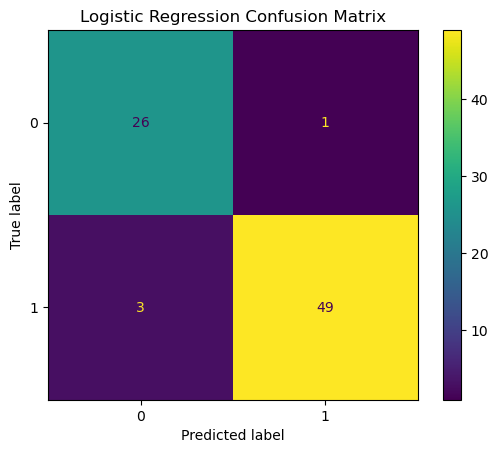

In [13]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [14]:
# Train the Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [15]:
# Make predictions

rf_pred = rf_model.predict(X_test)

In [16]:
# Evaluate the Random Forest model

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy : 0.9113924050632911
Precision: 0.9591836734693877
Recall   : 0.9038461538461539
F1 Score : 0.9306930693069307

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



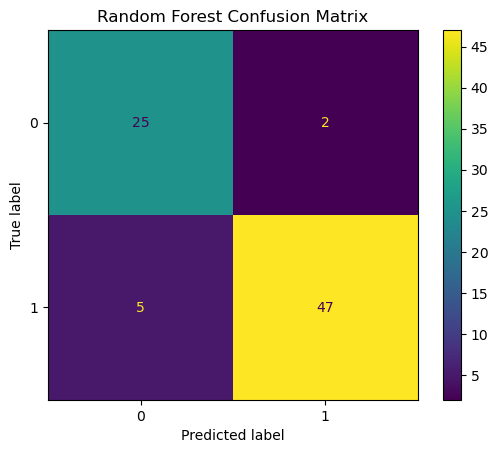

In [17]:
# Random Forest Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest Confusion Matrix")

plt.show()

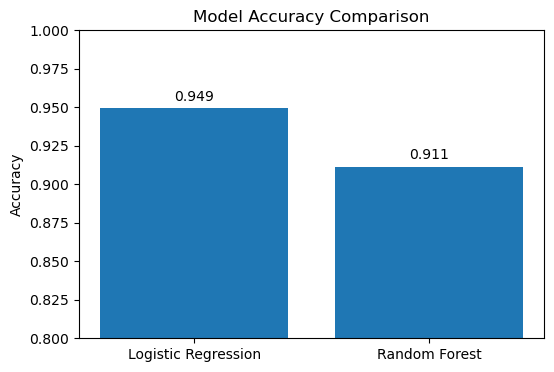

In [18]:
# Accuracy Comparison Bar Chart

models = ["Logistic Regression", "Random Forest"]

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0.8,1.0)

for i,v in enumerate(accuracies):
    plt.text(i,v+0.005,f"{v:.3f}",ha="center")

plt.show()

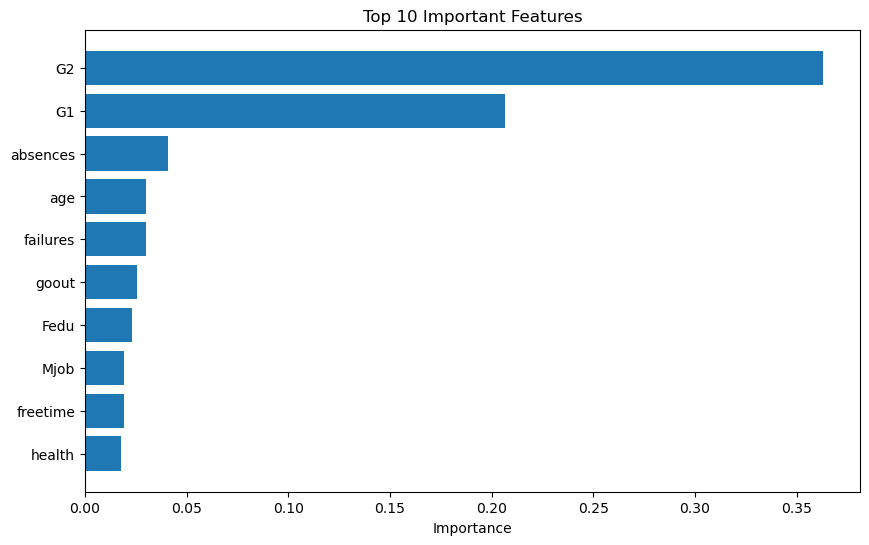

In [19]:
# Feature Importance

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [20]:
plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [21]:
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [22]:
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

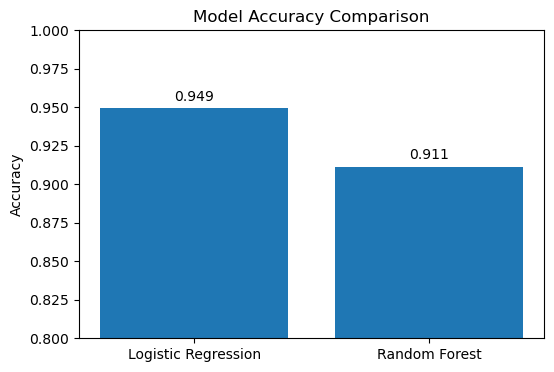

In [23]:
plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0.8,1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v+0.005, f"{v:.3f}", ha="center")

# Save BEFORE showing the graph
plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

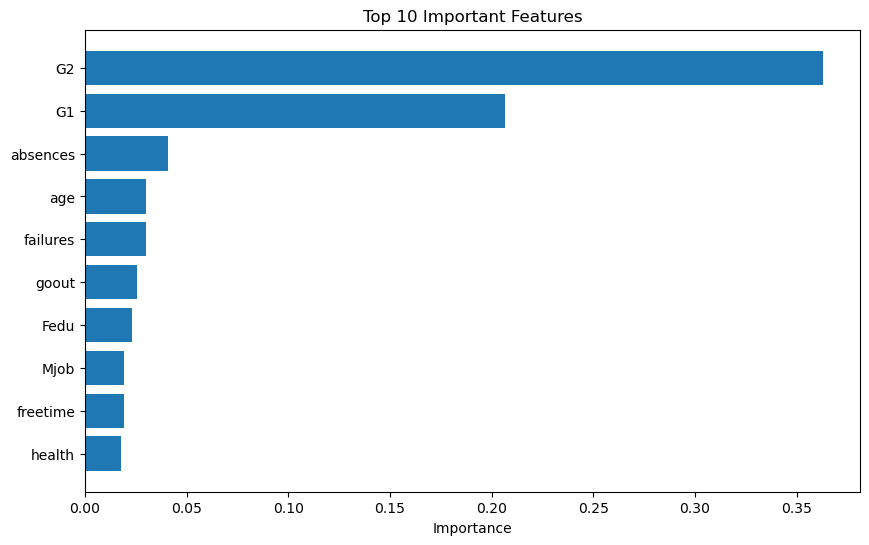

In [24]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

# Save BEFORE showing the graph
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [1]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

NameError: name 'LogisticRegression' is not defined